# On Numerical Dataset

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [281]:
df = pd.read_csv('titanic_toy.csv', usecols=['Age','Fare','Survived'])
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [282]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64

In [283]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Survived',axis=1),df['Survived'],test_size=0.2,random_state=2)

In [284]:
# Copying Data
X_train['Age_Imputed'] = X_train['Age']
X_test['Age_Imputed'] = X_test['Age']

X_train.head(10)

,Age,Fare,Age_Imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
213,30.0,13.0000,30.0
157,30.0,8.0500,30.0
780,13.0,7.2292,13.0
572,36.0,26.3875,36.0
77,NaN,8.0500,NaN


In [285]:
# Fill missing Age_Imputed values with randomly sampled non-missing Age values
# X_train.loc[
#     X_train['Age_Imputed'].isnull(),   # ← Rows to select
#     'Age_Imputed'                      # ← Column to select
# ]
X_train.loc[X_train['Age_Imputed'].isnull(),'Age_Imputed'] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test.loc[X_test['Age_Imputed'].isnull(),'Age_Imputed'] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

X_train

,Age,Fare,Age_Imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,2.0
493,71.0,49.5042,71.0
527,NaN,221.7792,23.0


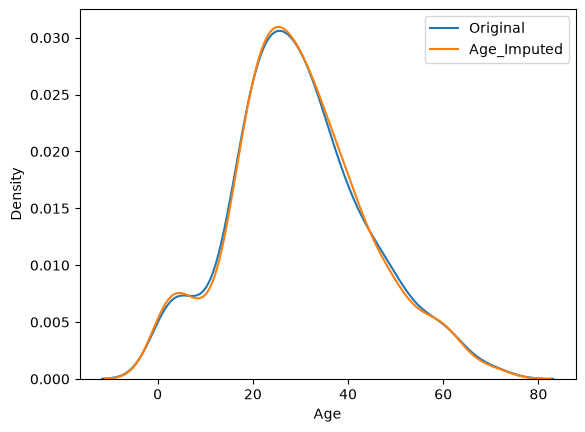

In [286]:
# Visualizing Distributon before and after Imputation
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_Imputed'], label='Age_Imputed')

plt.legend()

In [287]:
print('Original variable variance',X_train['Age'].var())
print('Imputed variable variance',X_train['Age_Imputed'].var())

Original variable variance 204.34951339046142
Imputed variable variance 202.27059004092985


In [288]:
# Checking Covariance
X_train.cov()

,Age,Fare,Age_Imputed
Age,204.349513,70.719262,204.349513
Fare,70.719262,2448.197914,47.840398
Age_Imputed,204.349513,47.840398,202.270590


<Axes: >

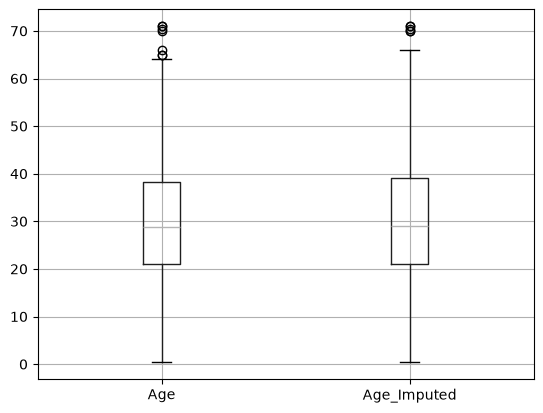

In [289]:
# Outliers Detection
X_train[['Age','Age_Imputed']].boxplot()

# On Categorical Dataset

In [307]:
data = pd.read_csv('house.csv',usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [308]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [309]:
X = data
y = data['SalePrice']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [310]:
# Copying Data
X_train['GarageQual_Imputed'] = X_train['GarageQual']
X_test['GarageQual_Imputed'] = X_test['GarageQual']

X_train['FireplaceQu_Imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_Imputed'] = X_test['FireplaceQu']

X_train.head(10)

,FireplaceQu,GarageQual,SalePrice,GarageQual_Imputed,FireplaceQu_Imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
1091,NaN,TA,160000,TA,NaN
590,NaN,TA,185900,TA,NaN
1298,Gd,TA,160000,TA,Gd
1255,Gd,TA,127500,TA,Gd
1202,Fa,TA,117000,TA,Fa


In [311]:
# Fill missing Age_Imputed values with randomly sampled non-missing Age values
# X_train.loc[
#     X_train['Age_Imputed'].isnull(),   # ← Rows to select
#     'Age_Imputed'                      # ← Column to select
# ]
X_train.loc[X_train['GarageQual_Imputed'].isnull(),'GarageQual_Imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test.loc[X_test['GarageQual_Imputed'].isnull(),'GarageQual_Imputed'] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train.loc[X_train['FireplaceQu_Imputed'].isnull(),'FireplaceQu_Imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test.loc[X_test['FireplaceQu_Imputed'].isnull(),'FireplaceQu_Imputed'] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_Imputed,FireplaceQu_Imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,TA
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [312]:
# Compare category frequencies before and after Random Sample Imputation to check if the original distribution is preserved
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_Imputed'].value_counts() / len(X_train),
     ], axis=1)
temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
TA,0.951043,0.952055
Fa,0.037171,0.035959
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [313]:
# Compare category frequencies before and after Random Sample Imputation to check if the original distribution is preserved
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_Imputed'].value_counts() / len(X_train),
     ], axis=1)
temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
Gd,0.494272,0.490582
TA,0.412439,0.413527
Fa,0.040917,0.041952
Po,0.027823,0.028253
Ex,0.024550,0.025685


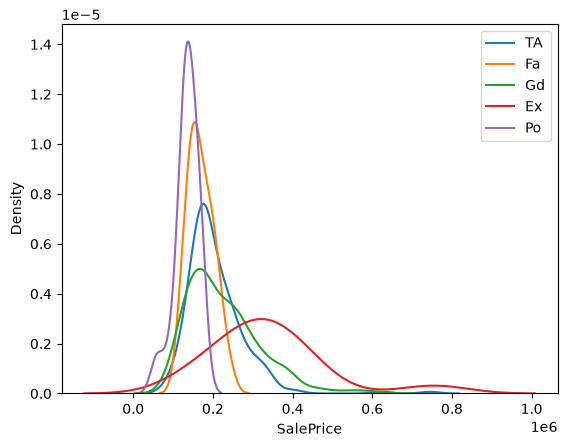

In [314]:
# Visually Compare SalePrice distribution for each FireplaceQu category before Imputation
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu'] == category]['SalePrice'],
        label=category
    )

plt.legend()

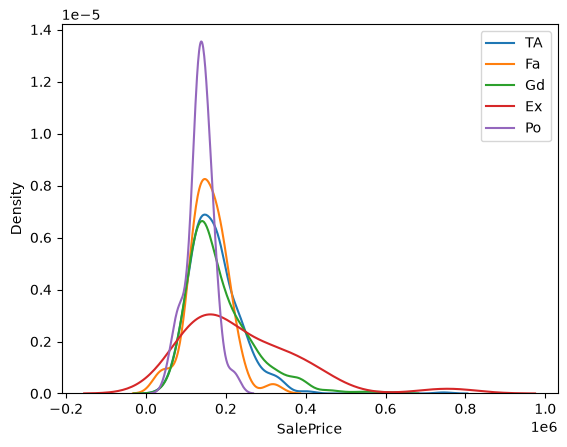

In [315]:
# Visually Compare SalePrice distribution for each FireplaceQu category after Imputation
for category in X_train['FireplaceQu_Imputed'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu_Imputed'] == category]['SalePrice'],
        label=category
    )

plt.legend()